In [2]:
import pandas as pd
import glob # This tool helps us find files in folders
import os

# 1. Define where your files are
data_path = "../data/"
# This looks for any file ending in .csv in your data folder
all_files = glob.glob(os.path.join(data_path, "*.csv"))

# 2. Filter out the 'clean' files we made earlier to avoid duplicates
raw_files = [f for f in all_files if "clean" not in f]

# 3. Create an empty list to store each country's data
li = []


for filename in raw_files:
    df = pd.read_csv(filename, index_col=None, header=0)

    # Extract the country name from the filename (e.g., 'ethiopia' from 'ethiopia.csv')
    country_name = os.path.basename(filename).replace(".csv", "").capitalize()
    df['Country'] = country_name

    # Standardize the date like we did in Tak 2
    df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

    li.append(df)

# 4. combine them all into one big DataFrame
master_df = pd.concat(li, axis=0, ignore_index=True)

# 5. Clean the master data (Handle -999 and small gaps)
master_df = master_df.replace(-999, pd.NA).ffill()

print(f"Master Dataset Created! Total rows: {len(master_df)}")
master_df['Country'].unique() # This should show all 5 countries

Master Dataset Created! Total rows: 20540


<StringArray>
['Ethiopia', 'Kenya', 'Nigeria', 'Sudan', 'Tanzania']
Length: 5, dtype: str

In [3]:
master_df['Country'].value_counts()

Country
Ethiopia    4108
Kenya       4108
Nigeria     4108
Sudan       4108
Tanzania    4108
Name: count, dtype: int64

C:\Users\Guyatu\AppData\Local\Temp\ipykernel_60764\853156964.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='Country', y='T2M', palette='Set2')


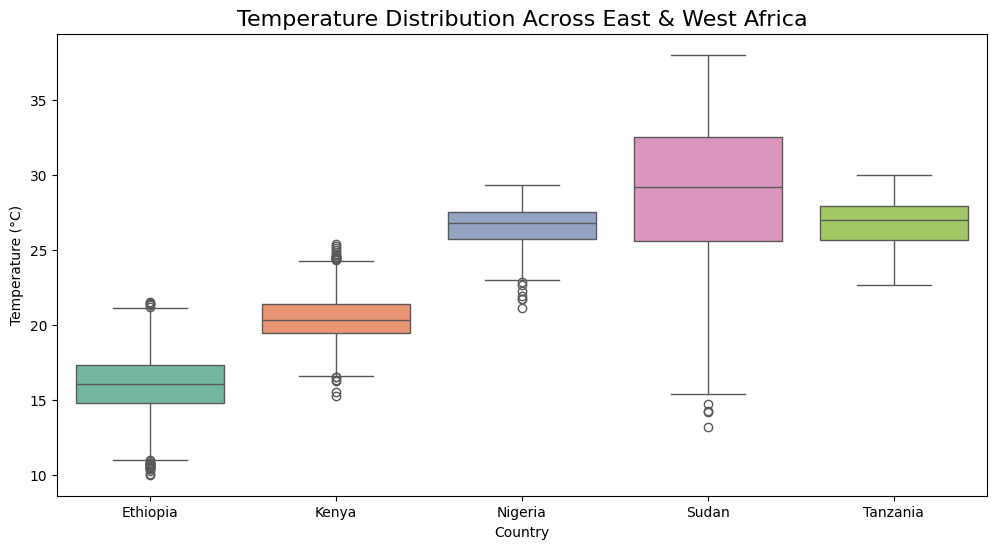

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df, x='Country', y='T2M', palette='Set2')

plt.title('Temperature Distribution Across East & West Africa', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.show()


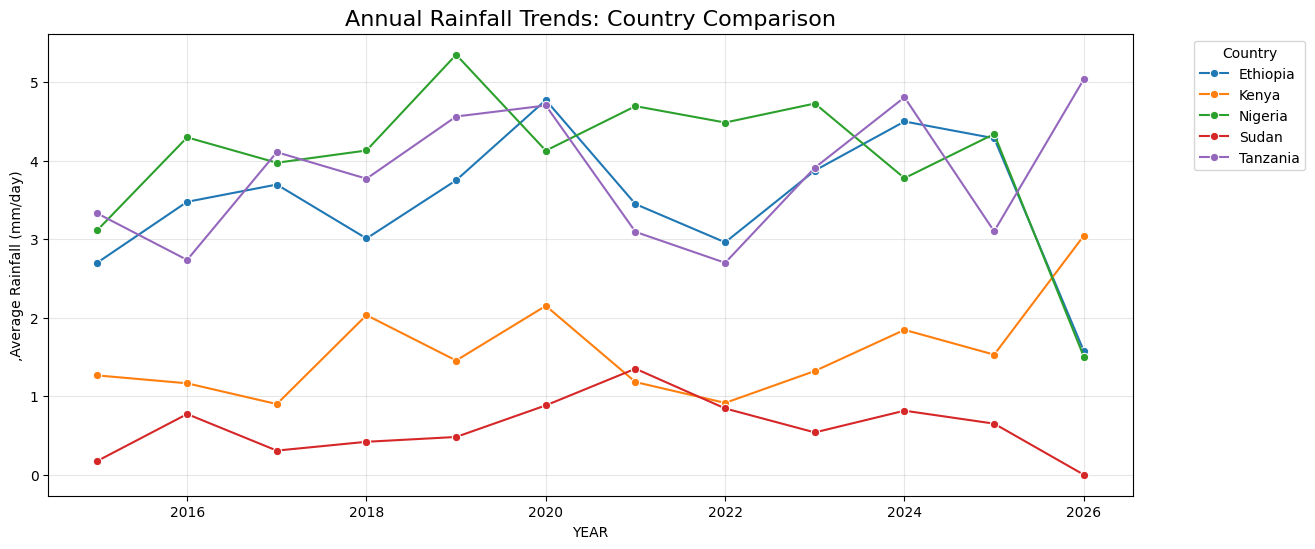

In [5]:
# Calculate the average rainfull per year for each country
yearly_rain = master_df.groupby(['Country', 'YEAR'])['PRECTOTCORR'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_rain, x='YEAR', y='PRECTOTCORR', hue='Country', marker='o')

plt.title('Annual Rainfall Trends: Country Comparison', fontsize=16)
plt.ylabel(',Average Rainfall (mm/day)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Guyatu\AppData\Local\Temp\ipykernel_60764\1252352143.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='Country', y='T2M', palette='Set2')


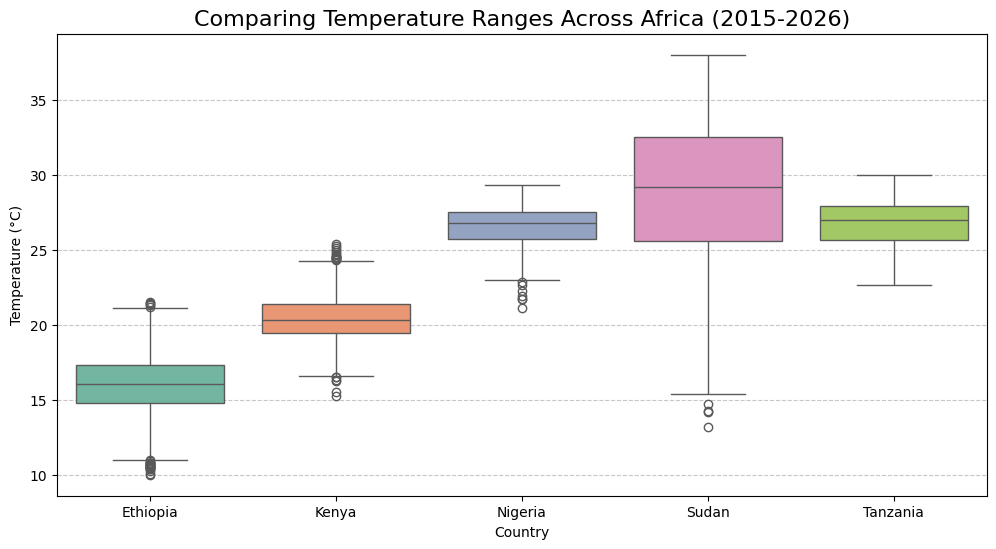

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# A box plot shows the Median, the "Normal Range," and Outliers (the dots)
sns.boxplot(data=master_df, x='Country', y='T2M', palette='Set2')

plt.title('Comparing Temperature Ranges Across Africa (2015-2026)', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

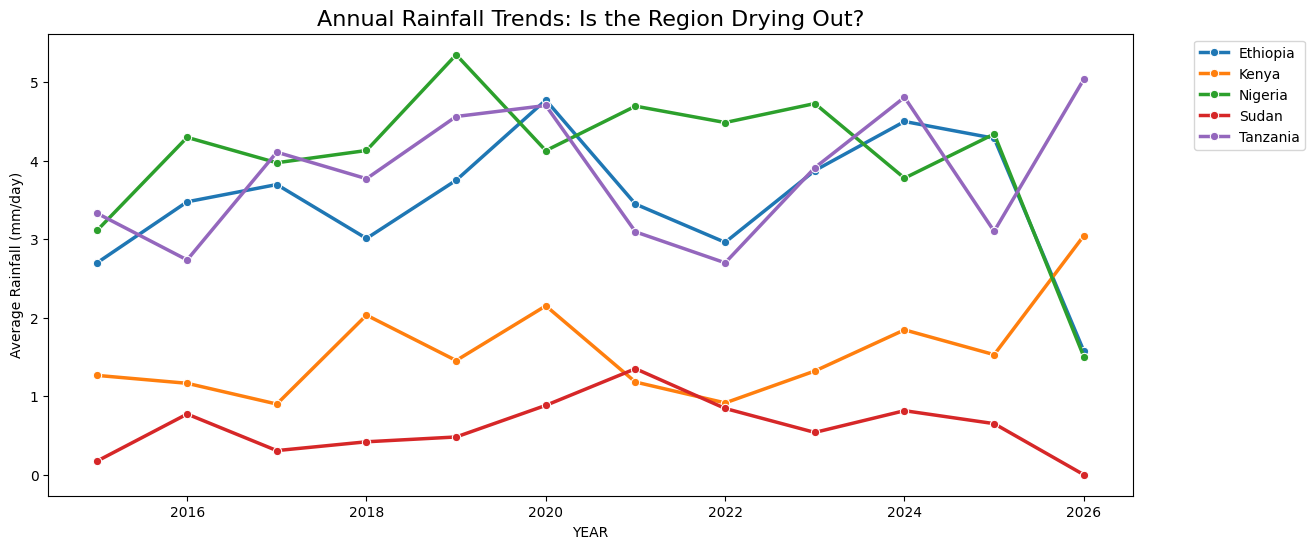

In [7]:
# 1. Group by country and year to see the 'Annual Picture'
yearly_rain = master_df.groupby(['Country', 'YEAR'])['PRECTOTCORR'].mean().reset_index()

# 2. Plot the lines
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_rain, x='YEAR', y='PRECTOTCORR', hue='Country', marker='o', linewidth=2.5)

plt.title('Annual Rainfall Trends: Is the Region Drying Out?', fontsize=16)
plt.ylabel('Average Rainfall (mm/day)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [8]:
master_df.to_csv("../data/master_climate_data.csv", index=False)